# Clean Data

In [1]:
#Cleaning Data
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('GlobalWeatherRepository.csv', on_bad_lines='skip')

# We only focus on thailand
df = df[df['location_name'] == 'Bangkok']
# Drop redundant data
# Using Celsius, km/h, mm
# Drop Fahrenheit, mph, inches and epoch time
cols_to_drop = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
    'last_updated_epoch',
    'country',
    'location_name',
    'timezone',
    'latitude',
    'longitude',
    'wind_degree',
    'wind_direction'
]
df = df.drop(columns=cols_to_drop)
# Drop complex time columns
complex_time_cols = ['sunrise', 'sunset', 'moonrise', 'moonset']
df = df.drop(columns=complex_time_cols)

# Datetime Features
# -------------------------
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df = df.drop(columns=['last_updated'])

def simplify_condition(text):
    text = str(text).lower()

    if 'thunder' in text or 'storm' in text:
        return 'Thunder'
    elif 'drizzle' in text:
        return 'Drizzle'
    elif 'rain' in text:
        return 'Rain'
    elif 'cloud' in text or 'overcast' in text:
        return 'Cloudy'
    elif 'sunny' in text or 'clear' in text:
        return 'Clear'
    else:
        return 'Other'

df['condition_text'] = df['condition_text'].apply(simplify_condition)

print(df['condition_text'].unique())

# Save
df.to_csv('Cleaned_Weather_Data.csv', index=False)

['Cloudy' 'Thunder' 'Rain' 'Clear' 'Drizzle']


In [2]:
#Label mapping
import json
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('Cleaned_Weather_Data.csv', on_bad_lines='skip')

# 2. Define categorical columns to encode
categorical_cols = ['condition_text', 'moon_phase']

# Dictionary to store the mapping for each column
label_mappings = {}

# 3. Process each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the data
    df[col] = le.fit_transform(df[col].astype(str))

    # Extract the mapping (index to class label)
    mapping = {int(index): label for index, label in enumerate(le.classes_)}

    # Store it in the main dictionary
    label_mappings[col] = mapping

# 4. Save the mappings to a JSON file
with open('label_mappings.json', 'w', encoding='utf-8') as file:
    json.dump(label_mappings, file, ensure_ascii=False, indent=4)

print("Dictionary saved successfully as 'label_mappings.json'")

Dictionary saved successfully as 'label_mappings.json'


In [3]:
#----------------------------
# EDA Setup (รันอันนี้ก่อน ไม่งั้นรันEDAกับFeatureไม่ได้)
#----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bangkok_df = pd.read_csv('Cleaned_Weather_Data.csv')

bangkok_df.info()
bangkok_df.describe()
bangkok_df.isnull().sum()

sns.set_style("whitegrid")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_celsius           696 non-null    float64
 1   condition_text                696 non-null    object 
 2   wind_kph                      696 non-null    float64
 3   pressure_mb                   696 non-null    float64
 4   precip_mm                     696 non-null    float64
 5   humidity                      696 non-null    int64  
 6   cloud                         696 non-null    int64  
 7   feels_like_celsius            696 non-null    float64
 8   visibility_km                 696 non-null    float64
 9   uv_index                      696 non-null    float64
 10  gust_kph                      696 non-null    float64
 11  air_quality_Carbon_Monoxide   696 non-null    float64
 12  air_quality_Ozone             696 non-null    float64
 13  air_q

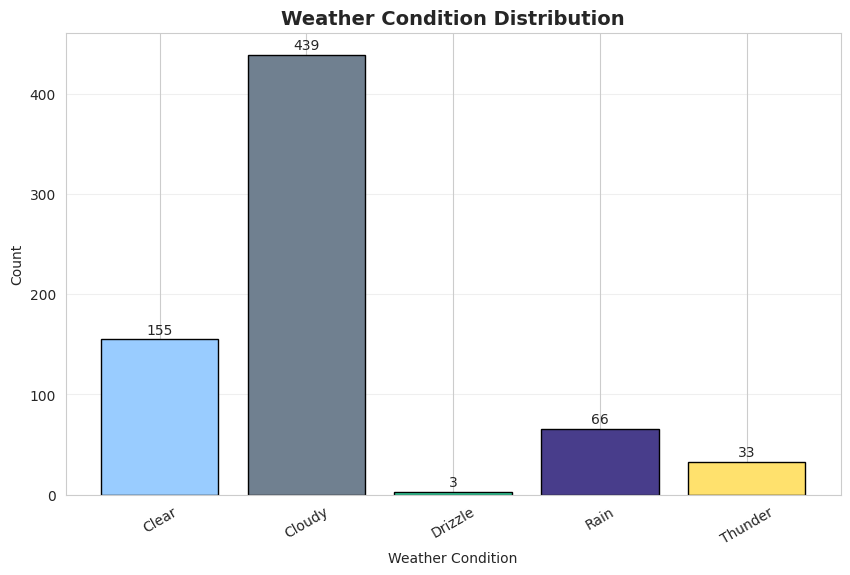

In [6]:
# Weather Con Distribution (Weather Classification)
cond_count = df['condition_text'].value_counts().sort_index()
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)

condition_map = mappings['condition_text']
cond_count.index = cond_count.index.map(lambda x: condition_map[str(x)])

plt.figure(figsize=(10,6))
bars = plt.bar(cond_count.index, cond_count.values,
               color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
               edgecolor='black')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             f'{int(y):,}', ha='center', fontsize=10)

plt.title("Weather Condition Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

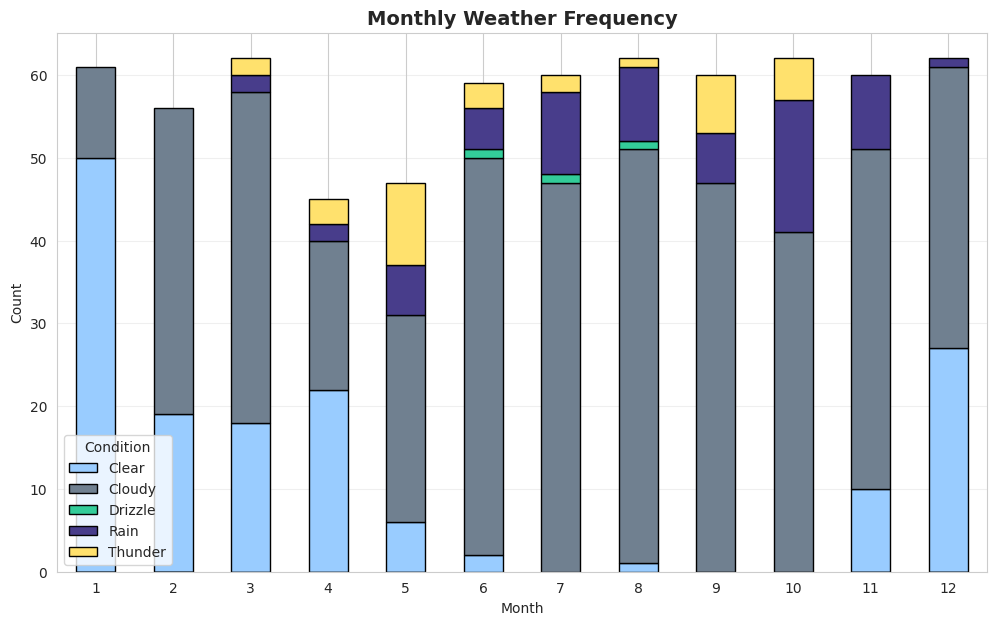

In [15]:
# Monthly Weather Freq (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])

monthly_weather = df.groupby(['month', 'condition_name']).size().unstack(fill_value=0)
monthly_weather.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#99CCFF','#708090','#33CC99','#483D8B','#ffe16d','#FF3399'],
    edgecolor='black'
)

plt.title("Monthly Weather Frequency", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.grid(axis='y', alpha=0.3)
plt.show()

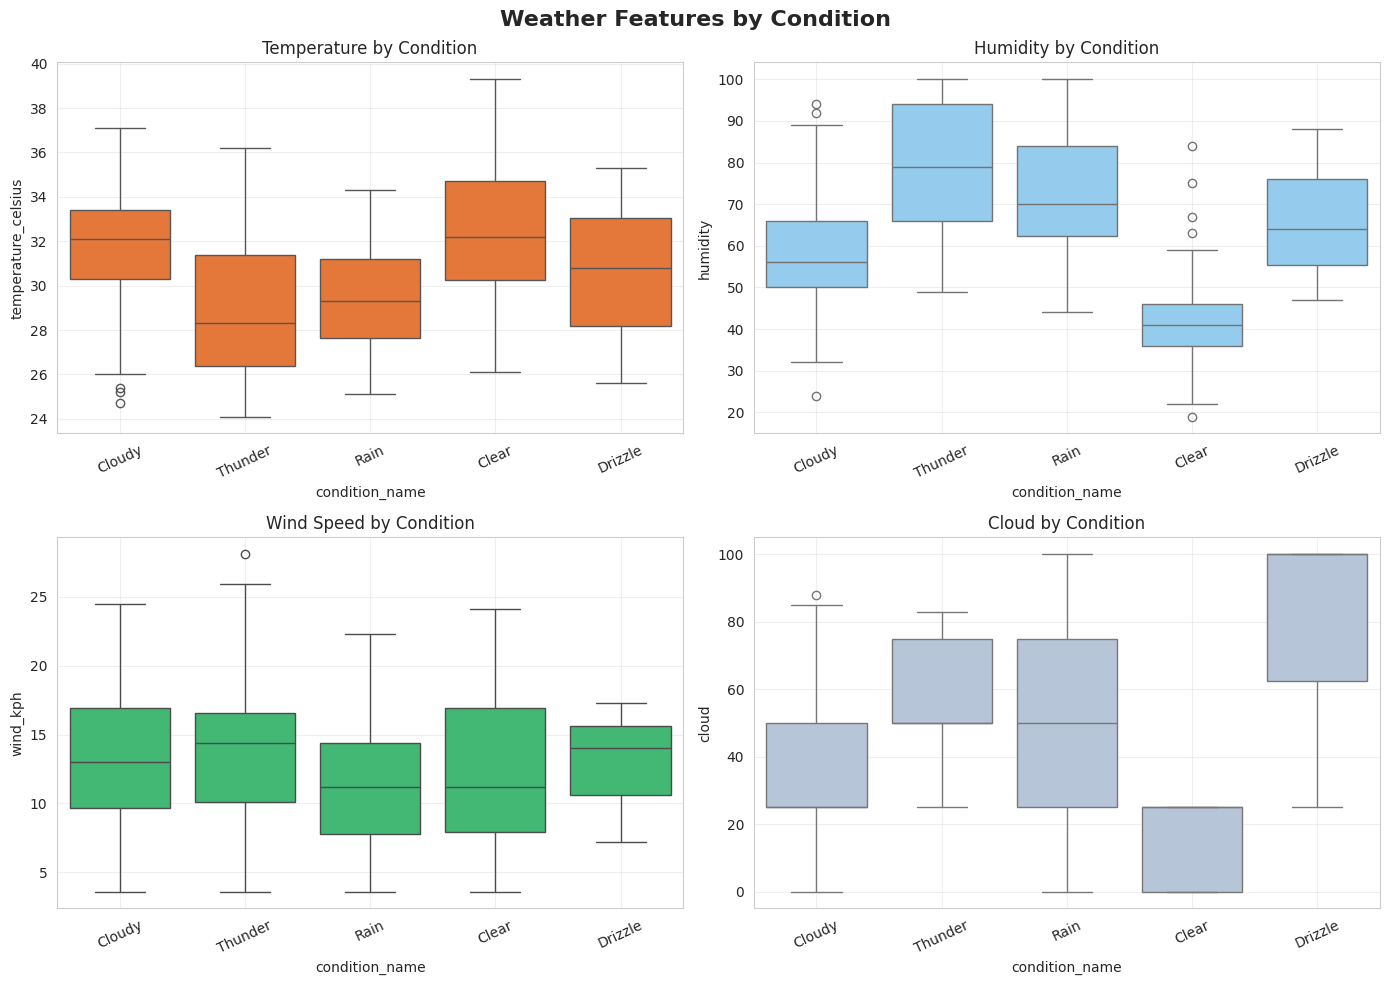

In [6]:
# Weather Features by Con (Weather Classification)
with open('label_mappings.json', 'r', encoding='utf-8') as f:
    mappings = json.load(f)
condition_map = mappings['condition_text']

df['condition_name'] = df['condition_text'].map(lambda x: condition_map[str(x)])
plot_df = df[['condition_name', 'temperature_celsius', 'humidity', 'wind_kph', 'cloud']]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Weather Features by Condition", fontsize=16, fontweight='bold')

# Temp
sns.boxplot(data=plot_df, x='condition_name', y='temperature_celsius',
            ax=axes[0,0], color='#ff701e')
axes[0,0].set_title("Temperature by Condition")

# Humidity
sns.boxplot(data=plot_df, x='condition_name', y='humidity',
            ax=axes[0,1], color='#87CEFA')
axes[0,1].set_title("Humidity by Condition")

# Wind
sns.boxplot(data=plot_df, x='condition_name', y='wind_kph',
            ax=axes[1,0], color='#2ecc71')
axes[1,0].set_title("Wind Speed by Condition")

# Cloud
sns.boxplot(data=plot_df, x='condition_name', y='cloud',
            ax=axes[1,1], color='#B0C4DE')
axes[1,1].set_title("Cloud by Condition")

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

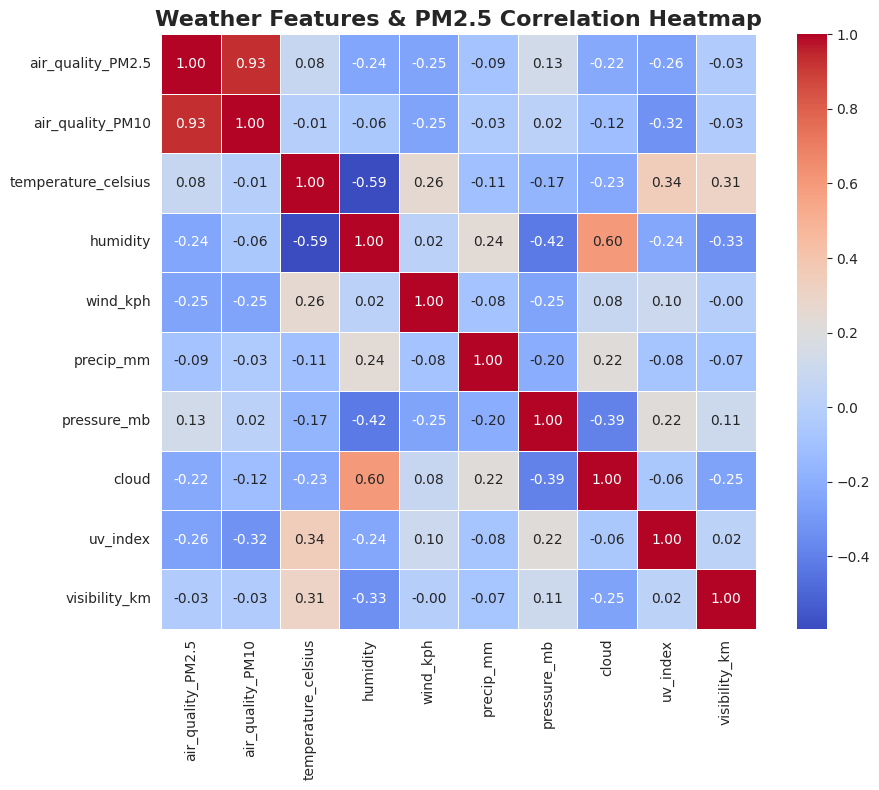

In [13]:
# Correlation Heatmap (PM2.5 Prediction)
cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb',
    'cloud',
    'uv_index',
    'visibility_km',
]
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkokhm_df = bangkok_df[cols]
corr = bangkokhm_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Weather Features & PM2.5 Correlation Heatmap",fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

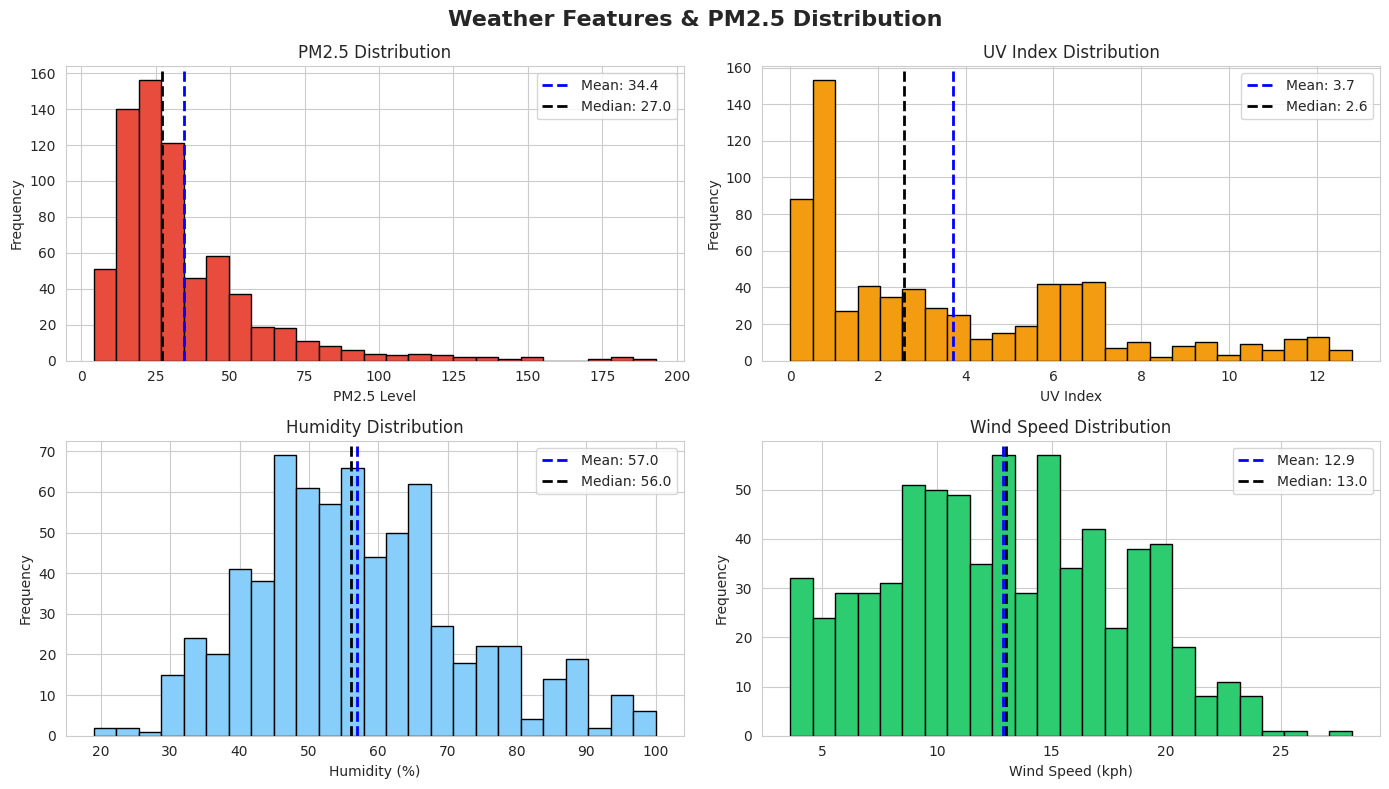

In [14]:
# Distribution (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Weather Features & PM2.5 Distribution", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'humidity', 'wind_kph']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

# PM2.5
mean_pm = bangkok_df['air_quality_PM2.5'].mean()
median_pm = bangkok_df['air_quality_PM2.5'].median()

axes[0,0].hist(bangkok_df['air_quality_PM2.5'], bins=25, color='#e74c3c', edgecolor='black')
axes[0,0].axvline(mean_pm, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_pm:.1f}')
axes[0,0].axvline(median_pm, color='black', linestyle='--', linewidth=2, label=f'Median: {median_pm:.1f}')
axes[0,0].set_title("PM2.5 Distribution")
axes[0,0].set_xlabel("PM2.5 Level")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# UV
mean_uv = bangkok_df['uv_index'].mean()
median_uv = bangkok_df['uv_index'].median()

axes[0,1].hist(bangkok_df['uv_index'], bins=25, color='#f39c12', edgecolor='black')
axes[0,1].axvline(mean_uv, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_uv:.1f}')
axes[0,1].axvline(median_uv, color='black', linestyle='--', linewidth=2, label=f'Median: {median_uv:.1f}')
axes[0,1].set_title("UV Index Distribution")
axes[0,1].set_xlabel("UV Index")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# Humidity
mean_h = bangkok_df['humidity'].mean()
median_h = bangkok_df['humidity'].median()

axes[1,0].hist(bangkok_df['humidity'], bins=25, color='#87CEFA', edgecolor='black')
axes[1,0].axvline(mean_h, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
axes[1,0].axvline(median_h, color='black', linestyle='--', linewidth=2, label=f'Median: {median_h:.1f}')
axes[1,0].set_title("Humidity Distribution")
axes[1,0].set_xlabel("Humidity (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# Wind Speed
mean_w = bangkok_df['wind_kph'].mean()
median_w = bangkok_df['wind_kph'].median()

axes[1,1].hist(bangkok_df['wind_kph'], bins=25, color='#2ecc71', edgecolor='black')
axes[1,1].axvline(mean_w, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_w:.1f}')
axes[1,1].axvline(median_w, color='black', linestyle='--', linewidth=2, label=f'Median: {median_w:.1f}')
axes[1,1].set_title("Wind Speed Distribution")
axes[1,1].set_xlabel("Wind Speed (kph)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

plt.tight_layout()
plt.show()

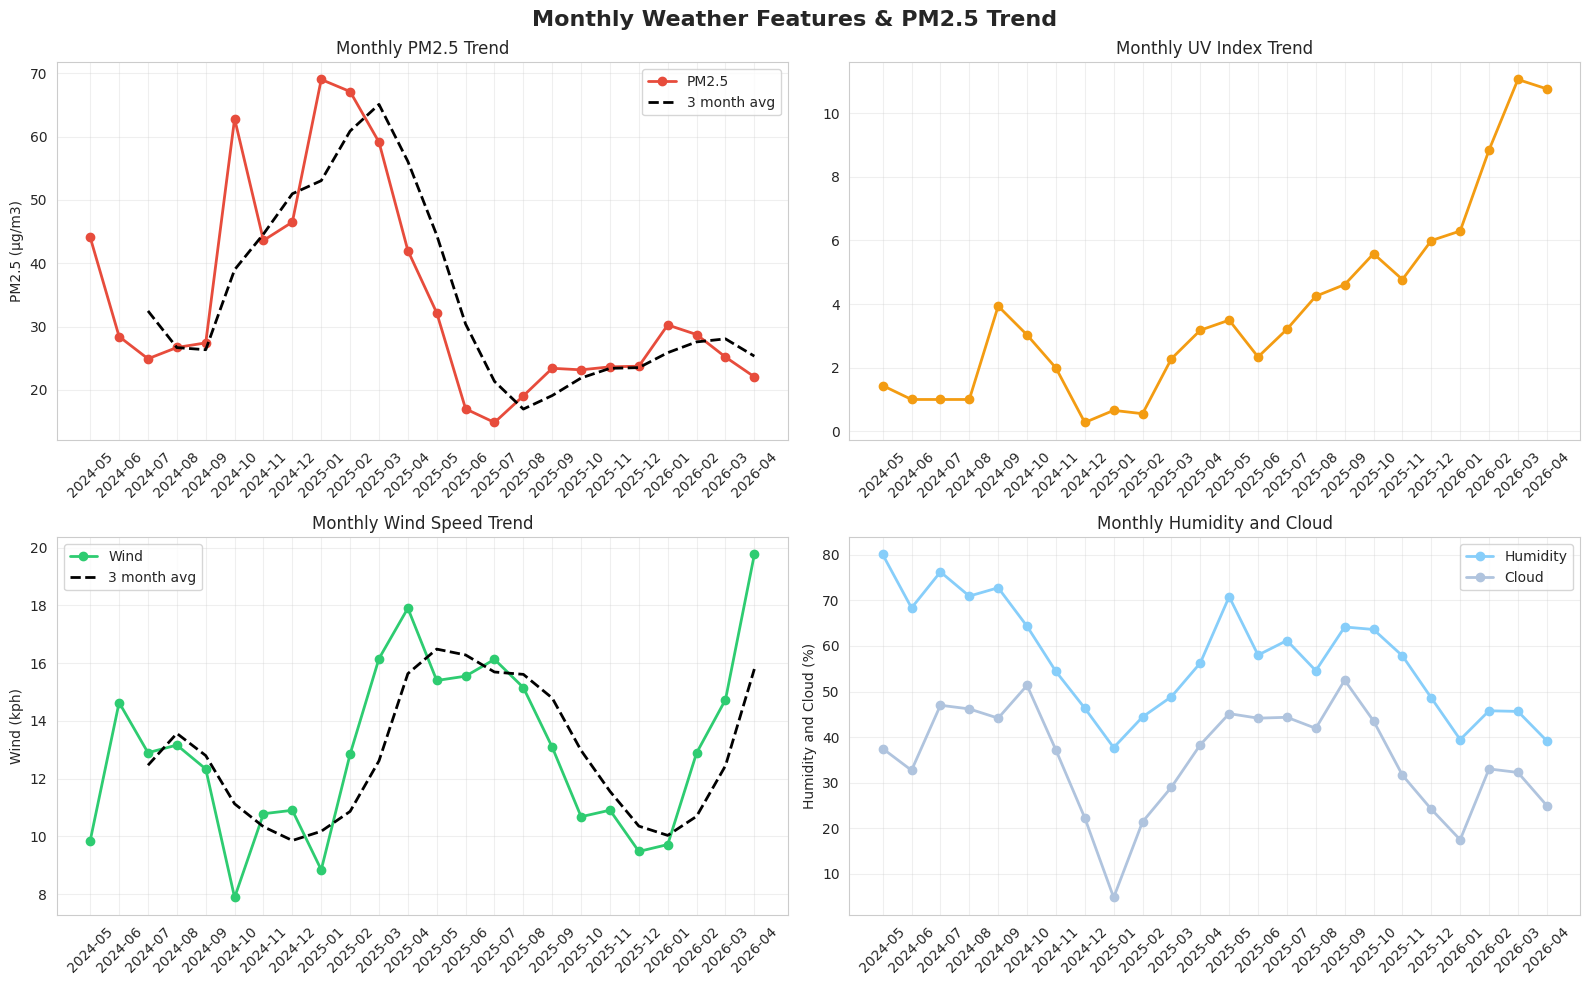

In [15]:
# Monthly Trend (PM2.5 Prediction)
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Monthly Weather Features & PM2.5 Trend", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'wind_kph', 'humidity', 'cloud']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df['year_month'] = (
    bangkok_df['year'].astype(int).astype(str) + '-' +
    bangkok_df['month'].astype(int).astype(str).str.zfill(2)
)
# monthly avg
monthly = bangkok_df.groupby('year_month')[cols].mean().reset_index()

# 3 month avg
monthly['pm_mavg3'] = monthly['air_quality_PM2.5'].rolling(3).mean()
monthly['wind_mavg3'] = monthly['wind_kph'].rolling(3).mean()

# PM2.5
axes[0,0].plot(monthly['year_month'], monthly['air_quality_PM2.5'],
               color='#e74c3c', marker='o', linewidth=2, label='PM2.5')
axes[0,0].plot(monthly['year_month'], monthly['pm_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[0,0].set_title("Monthly PM2.5 Trend")
axes[0,0].set_ylabel("PM2.5 (µg/m3)")
axes[0,0].legend()

# UV Index
axes[0,1].plot(monthly['year_month'], monthly['uv_index'],
               color='#f39c12', marker='o', linewidth=2)
axes[0,1].set_title("Monthly UV Index Trend")

# Wind
axes[1,0].plot(monthly['year_month'], monthly['wind_kph'],
               color='#2ecc71', marker='o', linewidth=2, label='Wind')
axes[1,0].plot(monthly['year_month'], monthly['wind_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[1,0].set_title("Monthly Wind Speed Trend")
axes[1,0].set_ylabel("Wind (kph)")
axes[1,0].legend()

# Humidity and Cloud
ax1 = axes[1,1]
ax2 = axes[1,1]

ax1.plot(monthly['year_month'], monthly['humidity'],
         color='#87CEFA', marker='o', linewidth=2, label='Humidity')

ax2.plot(monthly['year_month'], monthly['cloud'],
         color='#B0C4DE', marker='o', linewidth=2, label='Cloud')

ax1.set_title("Monthly Humidity and Cloud")
ax1.set_ylabel("Humidity and Cloud (%)")
ax1.legend()

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

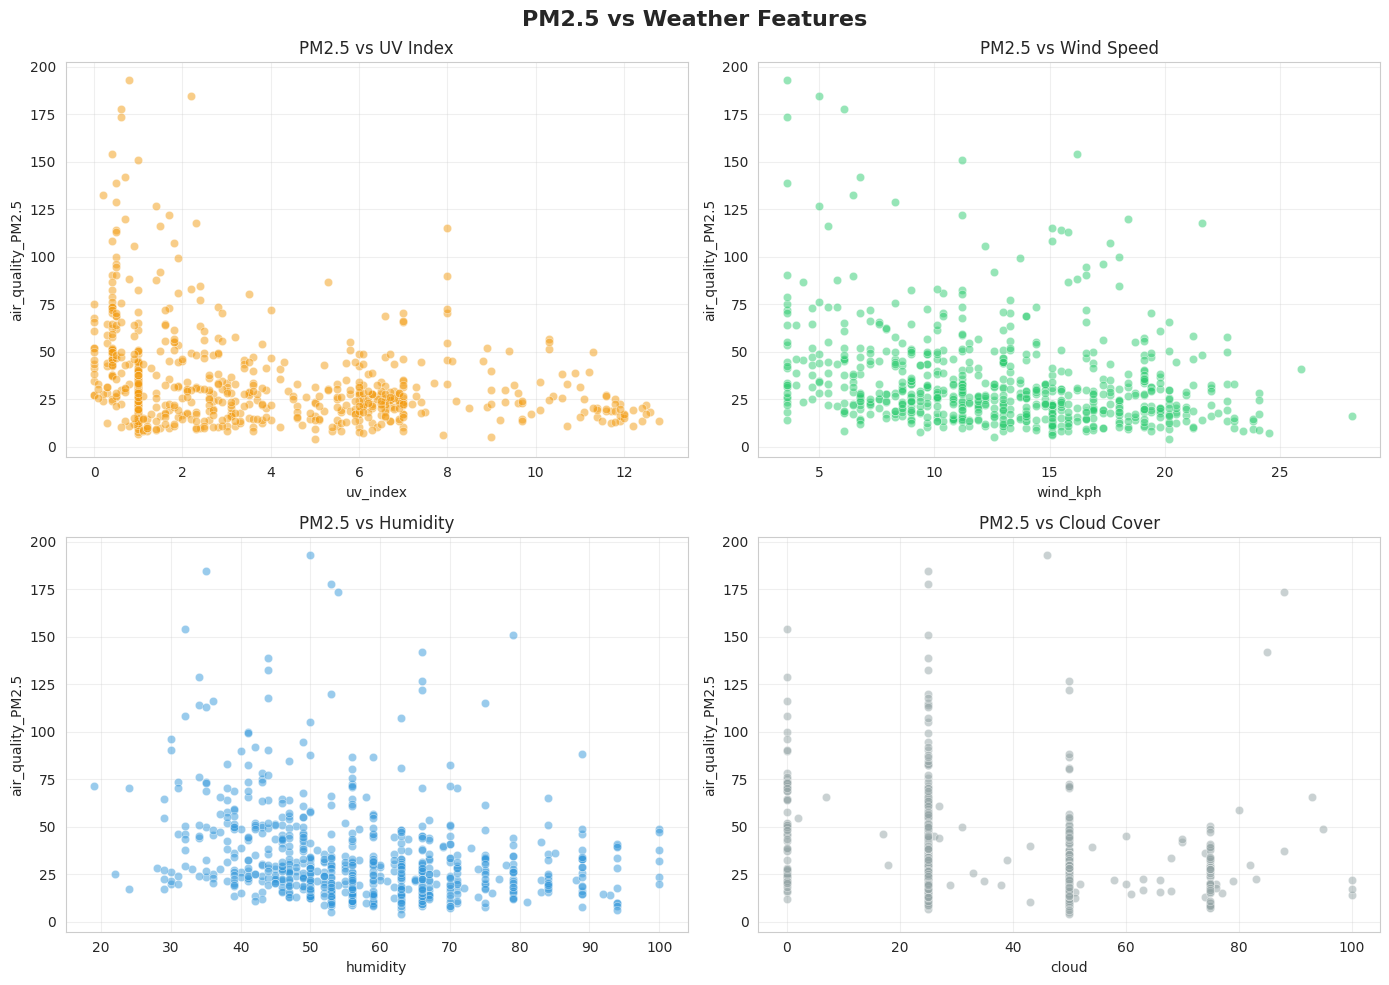

In [16]:
# PM2.5 Relationship (PM2.5 Prediction)
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("PM2.5 vs Weather Features", fontsize=16, fontweight='bold')

# PM2.5 vs UV
sns.scatterplot(data=df, x='uv_index', y='air_quality_PM2.5',
                ax=axes[0,0], color='#f39c12', alpha=0.5)
axes[0,0].set_title("PM2.5 vs UV Index")

# PM2.5 vs Wind
sns.scatterplot(data=df, x='wind_kph', y='air_quality_PM2.5',
                ax=axes[0,1], color='#2ecc71', alpha=0.5)
axes[0,1].set_title("PM2.5 vs Wind Speed")

# PM2.5 vs Humidity
sns.scatterplot(data=df, x='humidity', y='air_quality_PM2.5',
                ax=axes[1,0], color='#3498db', alpha=0.5)
axes[1,0].set_title("PM2.5 vs Humidity")

# PM2.5 vs Cloud
sns.scatterplot(data=df, x='cloud', y='air_quality_PM2.5',
                ax=axes[1,1], color='#95a5a6', alpha=0.5)
axes[1,1].set_title("PM2.5 vs Cloud Cover")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
#----------------------------
# Feature Engineering
#----------------------------

# Season from month
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "Cool"
    elif month in [3, 4, 5]:
        return "Hot"
    else:
        return "Rainy"

bangkok_df['season'] = bangkok_df['month'].apply(get_season)

bangkok_df[['month', 'season']].sample(10)

,month,season
117,9,Rainy
348,5,Hot
46,7,Rainy
669,3,Hot
665,3,Hot
119,9,Rainy
297,3,Hot
435,7,Rainy
539,11,Cool
59,7,Rainy


In [12]:
# Lag 1 day
bangkok_df['pm_lag'] = bangkok_df['air_quality_PM2.5'].shift(1)
bangkok_df['wind_lag'] = bangkok_df['wind_kph'].shift(1)
bangkok_df['uv_lag'] = bangkok_df['uv_index'].shift(1)
bangkok_df['humidity_lag'] = bangkok_df['humidity'].shift(1)
bangkok_df['cloud_lag'] = bangkok_df['cloud'].shift(1)

bangkok_df[['air_quality_PM2.5','pm_lag',
            'wind_kph','wind_lag',
            'uv_index','uv_lag',
            'humidity','humidity_lag',
            'cloud','cloud_lag']].head(10)

,air_quality_PM2.5,pm_lag,wind_kph,wind_lag,uv_index,uv_lag,humidity,humidity_lag,cloud,cloud_lag
0,115.2,NaN,15.1,NaN,8.0,NaN,75,NaN,25,NaN
1,150.8,115.2,11.2,15.1,1.0,8.0,79,75.0,25,25.0
2,33.2,150.8,9.0,11.2,1.0,1.0,75,79.0,25,25.0
3,14.8,33.2,9.0,9.0,1.0,1.0,89,75.0,50,25.0
4,65.0,14.8,6.1,9.0,1.0,1.0,84,89.0,25,50.0
5,25.9,65.0,3.6,6.1,1.0,1.0,89,84.0,25,25.0
6,26.1,25.9,9.0,3.6,1.0,1.0,75,89.0,50,25.0
7,28.5,26.1,6.8,9.0,1.0,1.0,94,75.0,50,50.0
8,31.7,28.5,13.0,6.8,1.0,1.0,75,94.0,25,50.0
9,18.3,31.7,6.1,13.0,1.0,1.0,79,75.0,25,25.0


In [13]:
# Interaction
bangkok_df['Humidity_over_Cloud'] = bangkok_df['humidity'] / bangkok_df['cloud']
bangkok_df['Humidity_over_Temp'] = bangkok_df['humidity'] / bangkok_df['temperature_celsius']
bangkok_df['Humidity_over_Visibility'] = bangkok_df['humidity'] / bangkok_df['visibility_km']
bangkok_df['Gust_over_Wind'] = bangkok_df['gust_kph'] / bangkok_df['wind_kph']
bangkok_df[[ 'temperature_celsius',
           'humidity',
           'visibility_km',
           'cloud',
           'gust_kph',
           'wind_kph',
           'Humidity_over_Cloud',
           'Humidity_over_Temp',
           'Humidity_over_Visibility',
           'Gust_over_Wind']].head(10)

,temperature_celsius,humidity,visibility_km,cloud,gust_kph,wind_kph,Humidity_over_Cloud,Humidity_over_Temp,Humidity_over_Visibility,Gust_over_Wind
0,31.0,75,10.0,25,18.2,15.1,3.00,2.419355,7.500000,1.205298
1,30.0,79,10.0,25,20.9,11.2,3.16,2.633333,7.900000,1.866071
2,31.0,75,10.0,25,24.1,9.0,3.00,2.419355,7.500000,2.677778
3,27.0,89,9.0,50,23.2,9.0,1.78,3.296296,9.888889,2.577778
4,30.0,84,10.0,25,24.8,6.1,3.36,2.800000,8.400000,4.065574
5,27.0,89,10.0,25,37.5,3.6,3.56,3.296296,8.900000,10.416667
6,30.0,75,10.0,50,17.0,9.0,1.50,2.500000,7.500000,1.888889
7,27.0,94,8.0,50,14.6,6.8,1.88,3.481481,11.750000,2.147059
8,30.0,75,10.0,25,20.2,13.0,3.00,2.500000,7.500000,1.553846
9,30.0,79,10.0,25,13.1,6.1,3.16,2.633333,7.900000,2.147541


In [14]:
# Day/Night
bangkok_df['is_day'] = bangkok_df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
bangkok_df[['hour',
           'is_day']].sample(10)

,hour,is_day
303,16,1
25,21,0
31,20,0
532,15,1
663,13,1
252,17,1
266,17,1
107,19,0
204,18,1
193,18,1
